# NLP analysis for Game of Throne

import libraries

In [1]:
import spacy
import torch
from transformers import pipeline

import seaborn as sns
import matplotlib.pyplot as plt

print("Python / torch / spaCy check:")
print("torch:", torch.__version__)
print("spaCy:", spacy.__version__)

Python / torch / spaCy check:
torch: 2.5.1+cpu
spaCy: 3.8.11


test if everything is installed properly. warning is ok

In [ ]:
# spaCy English
nlp_en = spacy.load("en_core_web_trf")
doc = nlp_en("Apple is looking at buying a U.K. startup for $1 billion.")
print("EN entities:", [(ent.text, ent.label_) for ent in doc.ents])

# spaCy French
nlp_fr = spacy.load("fr_core_news_lg")
doc_fr = nlp_fr("Emmanuel Macron rencontre des chercheurs à Paris.")
print("FR entities:", [(ent.text, ent.label_) for ent in doc_fr.ents])

# Hugging Face NER
ner = pipeline("ner", model="dslim/bert-large-NER", aggregation_strategy="simple")
print("HF entities:", ner("Hugging Face Inc. is based in New York City."))

In [4]:
import re
import pandas as pd

We read every book and split every chapter.

We store each chapter in a pandas dataframe.

In [ ]:
books = []
chapters_text = []
chapters_title = []

for i in range(1,6):
    with open(f'books/GOT{i}.txt','r') as fp:
        book = fp.read()
        pattern = r"\n{2,}"
        chapters = re.split(pattern, book, flags=re.IGNORECASE)
       
        for e,v in enumerate(chapters):
            if e%2 == 0:
                chapters_title.append(v.strip().title())
            else:
                chapters_text.append(v.strip())
                books.append(i)

chapters_title = [c for c in chapters_title if c]
df = pd.DataFrame.from_dict({'book':books, 'title':chapters_title, 'text':chapters_text})
df

,book,title,text
0,1,Prologue,"""We should start back,"" Gared urged as the woo..."
1,1,Bran,"The morning had dawned clear and cold, with a ..."
2,1,Catelyn,Catelyn had never liked this godswood.\n\tShe ...
3,1,Daenerys,Her brother held the gown up for her inspectio...
4,1,Eddard,The visitors poured through the castle gates i...
...,...,...,...
340,5,Jon,"Let them die,"" said Queen Selyse.\n\tIt was th..."
341,5,Trueborn Lord Of Winterfell.,"""Snow?"" said Tormund Giantsbane. ""You look lik..."
342,5,The Queen'S Hand,The Dornish prince was three days dying.\n\tHe...
343,5,Daenerys,The hill was a stony island in a sea of green....


### BOW Bag of Word

In [ ]:
from collections import Counter

In [ ]:
df.iat[1,2][0:700]

"The morning had dawned clear and cold, with a crispness that hinted at the end of summer. They set forth at daybreak to see a man beheaded, twenty in all, and Bran rode among them, nervous with excitement. This was the first time he had been deemed old enough to go with his lord father and his brothers to see the king's justice done. It was the ninth year of summer, and the seventh of Bran's life.\n\tThe man had been taken outside a small holdfast in the hills. Robb thought he was a wildling, his sword sworn to Mance Rayder, the King-beyond-the-Wall. It made Bran's skin prickle to think of it. He remembered the hearth tales Old Nan told them. The wildlings were cruel men, she said, slavers and"

In [ ]:
bow_no_nlp_counter = Counter([w for w in re.split(r"[\b\s\W]", df.iat[1,2]) if w])

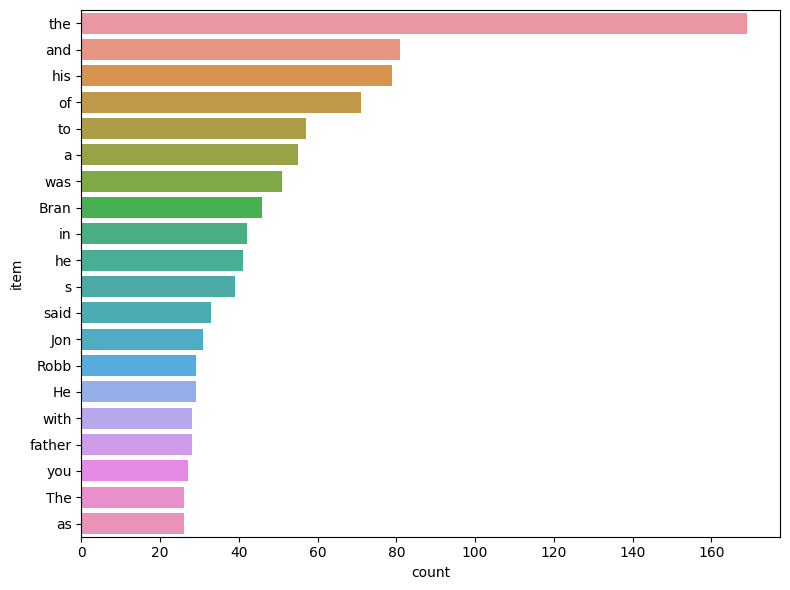

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=pd.DataFrame(bow_no_nlp_counter.most_common(20), columns=["item","count"]),
    x="count",
    y="item"
)
plt.tight_layout()
plt.show()

### BOW Bag of Word STOPPED

In [ ]:
from spacy.lang.en.stop_words import STOP_WORDS

bow_no_nlp_stop_counter = Counter([w for w in re.split(r"[\b\s\W]", df.iat[1,2]) if w.lower() not in STOP_WORDS and len(w) > 1])

You can see two times the word father...

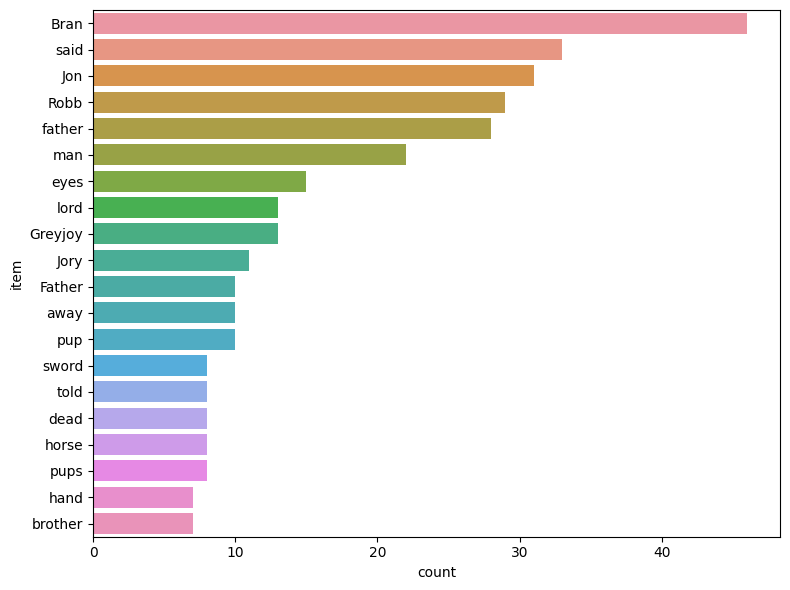

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=pd.DataFrame(bow_no_nlp_stop_counter.most_common(20), columns=["item","count"]),
    x="count",
    y="item"
)
plt.tight_layout()
plt.show()

### BOW Bag of Word STOPPED lemmatized

#### POS TAGGING

- __Text__: The original word text.
- __Lemma__: The base form of the word.
- __POS__: The simple UPOS part-of-speech tag.
- __Tag__: The detailed part-of-speech tag.
- __Dep__: Syntactic dependency, i.e. the relation between tokens.
- __Shape__: The word shape – capitalization, punctuation, digits.
- __is alpha__: Is the token an alpha character?
- __is stop__: Is the token part of a stop list, i.e. the most common words of the language?

In [ ]:
doc = nlp_en(df.iat[1,2])

for token in doc:
    print(token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
            token.shape_, token.is_alpha, token.is_stop)

The the DET DT det Xxx True True
morning morning NOUN NN nsubj xxxx True False
had have AUX VBD aux xxx True True
dawned dawn VERB VBN ROOT xxxx True False
clear clear ADJ JJ oprd xxxx True False
and and CCONJ CC cc xxx True True
cold cold ADJ JJ conj xxxx True False
, , PUNCT , punct , False False
with with ADP IN prep xxxx True True
a a DET DT det x True True
crispness crispness NOUN NN pobj xxxx True False
that that PRON WDT nsubj xxxx True True
hinted hint VERB VBD relcl xxxx True False
at at ADP IN prep xx True True
the the DET DT det xxx True True
end end NOUN NN pobj xxx True False
of of ADP IN prep xx True True
summer summer NOUN NN pobj xxxx True False
. . PUNCT . punct . False False
They they PRON PRP nsubj Xxxx True True
set set VERB VBD ROOT xxx True False
forth forth ADV RB advmod xxxx True False
at at ADP IN prep xx True True
daybreak daybreak NOUN NN pobj xxxx True False
to to PART TO aux xx True True
see see VERB VB advcl xxx True True
a a DET DT det x True True
man man

In [ ]:
bow_nlp_stop_counter = Counter([token.lemma_ for token in doc if not token.is_stop and token.pos_ not in ['PUNCT', 'SPACE']])

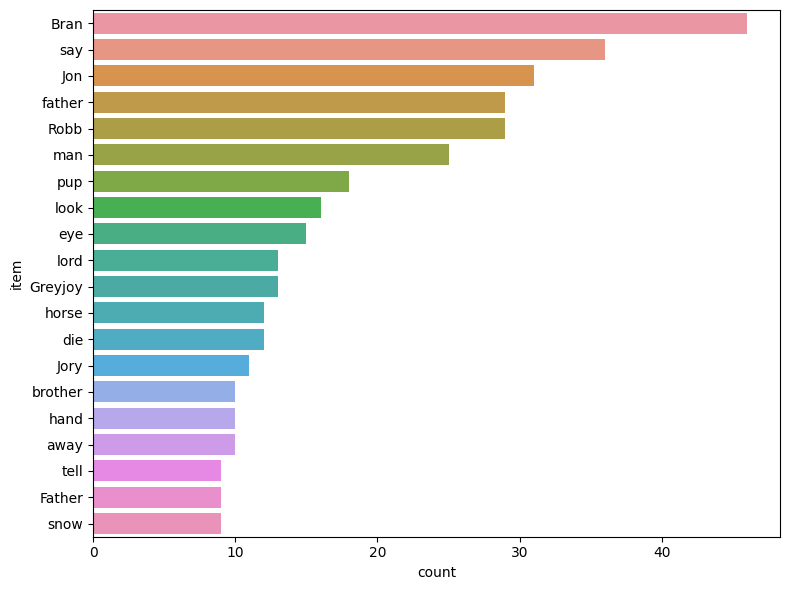

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=pd.DataFrame(bow_nlp_stop_counter.most_common(20), columns=["item","count"]),
    x="count",
    y="item"
)
plt.tight_layout()
plt.show()

### NER with transformers 

In [ ]:
%%time
def extract_persons_NER_HF(text):
    persons = set()
    clean = text.replace('\n\t',' ').replace("\'","'")

    entities = ner(clean, aggregation_strategy='average')

    for e in entities:
        if e.get('entity_group') == 'PER':
            persons.add(e.get('word'))
    return list(persons)

df['persons_HF'] = df.text.apply(extract_persons_NER_HF)

16min 8s ± 22.9 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
entities = nlp_en(df.iat[1,2]).ents

In [ ]:
set([(e.text, e.label_) for e in entities if e.label_ == 'PERSON'])

['summer',
 'twenty',
 'Bran',
 'first',
 'the ninth year',
 'summer',
 'seventh',
 'Bran',
 'Robb',
 'Mance Rayder',
 'Bran',
 'Nan',
 'Robb',
 "the Night's Watch",
 'Robb',
 'Jon',
 'Bran',
 'seven',
 'Starks',
 'Winterfell',
 'Bran',
 'his thirty-five years',
 'this day',
 'evening',
 'Father',
 'Bran',
 'Stark',
 'Winterfell',
 'Bran',
 'two',
 'Eddard Stark',
 'Theon Greyjoy',
 'Robb',
 'Valyrian',
 'Valyrian',
 'Jory Cassel',
 'Ice',
 'Robert',
 'Baratheon',
 'First',
 'Rhoynar',
 'First',
 'the Seven Kingdoms',
 'Eddard',
 'Stark',
 'Winterfell',
 'Bran',
 'Jon Snow',
 'Bran',
 'One',
 'Bran',
 'Greyjoy',
 'nineteen',
 'Jon',
 'Greyjoy',
 'Bran',
 'Bran',
 'Jon',
 'Jon',
 'fourteen',
 'Winterfell',
 'Bran',
 'Robb',
 'Tullys',
 'Riverrun',
 'Jon Snow',
 'Stark',
 'Jon',
 'Robb',
 'Jon',
 'Robb',
 'Robb',
 'half',
 'Robb',
 'Jon',
 'Robb',
 'Robb',
 'Jon',
 'Bran',
 'Robb',
 'Bran',
 'Bran',
 'Robb',
 'Jon',
 'Bran',
 'Bran',
 'Nan',
 "the Night's Watch",
 'Bran',
 'Robert',
 'Ta

In [ ]:
%%time
def extract_persons_SPACY(text):
    persons = set()
    
    clean = text.replace('\n\t',' ').replace("\'","'")
    
    doc = nlp_en(clean)

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            persons.add(ent.text)
    return list(persons)
    
df['persons_SP'] = df.text.apply(extract_persons_SPACY)

CPU times: user 4h 4min 7s, sys: 17min 18s, total: 4h 21min 26s
Wall time: 52min 29s


In [ ]:
df['persons_SP']

0      [Waymar, Royce, Will, Wildling, Aemon, Mallist...
1      [Father, Starks, Jory Cassel, Rickon, Baratheo...
2      [Starks, Eyrie, Rickon, Tullys, Nan, Pycelle, ...
3      [Dany, Myr, Willem, Daenerys, Daenerys Stormbo...
4      [Father, Sandor Clegane, The Hand of the King,...
                             ...                        
340    [Starks, Cregan Karstark, Sealskinner, Leather...
341    [Mully, Wun Wun's, Bowen Marsh, Rickon, Ygon O...
342    [The Green Grace, Straw, Widower, Astapor, Cat...
343    [Dany, Daenerys, Groleo, Khal Jhaqo, Ser Barri...
344    [Joff, Nym, Taena Merryweather, Taena, Rhaegar...
Name: persons_SP, Length: 345, dtype: object

In [ ]:
df["len_HF"] = df["persons_HF"].apply(len)
df["len_SP"] = df["persons_SP"].apply(len)

df["len_diff"] = df["len_HF"] - df["len_SP"]

df["set_HF"] = df["persons_HF"].apply(set)
df["set_SP"] = df["persons_SP"].apply(set)

df["only_HF"] = df.apply(lambda r: r["set_HF"] - r["set_SP"], axis=1)
df["only_SP"] = df.apply(lambda r: r["set_SP"] - r["set_HF"], axis=1)
df["disjoint"] = df.apply(lambda r: r["set_HF"] ^ r["set_SP"], axis=1)
df["intersection"] = df.apply(lambda r: r["set_HF"] & r["set_SP"], axis=1)

df["n_only_HF"] = df["only_HF"].apply(len)
df["n_only_SP"] = df["only_SP"].apply(len)
df["n_disjoint"] = df["disjoint"].apply(len)
df["n_intersection"] = df["intersection"].apply(len)

df["jaccard"] = df.apply(
    lambda r: len(r["intersection"]) / len(r["set_HF"] | r["set_SP"])
    if len(r["set_HF"] | r["set_SP"]) > 0 else 0,
    axis=1
)

In [ ]:
df[[
    "persons_HF", "persons_SP",
    "len_HF", "len_SP", "len_diff",
    "n_only_HF", "n_only_SP", "n_disjoint",
    "jaccard"
]].iat[0,1]

['Waymar',
 'Royce',
 'Will',
 'Wildling',
 'Aemon',
 'Mallisters',
 'Gared',
 'Ser Waymar',
 'Robert',
 'Mallister',
 'Waymar Royce',
 'Mormont']

/Users/fabien/.pyenv/versions/3.11.0/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


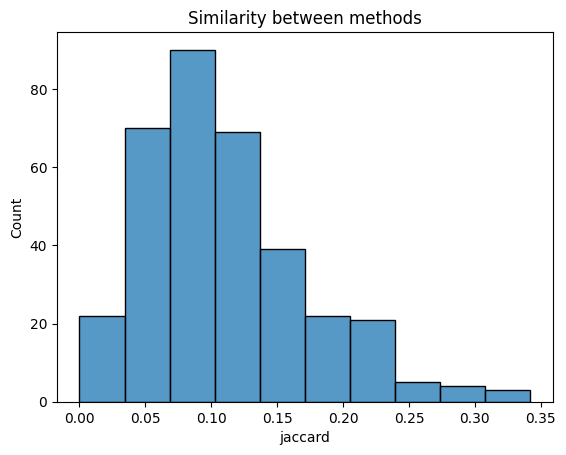

In [ ]:
plt.figure()
sns.histplot(df["jaccard"], bins=10)
plt.title("Similarity between methods")
plt.show()

In [ ]:
df.to_pickle('./data/GOT-NER-compare.pickle')

In [ ]:
df

,book,title,text,persons,persons_HF,persons_SP,len_HF,len_SP,len_diff,set_HF,set_SP,only_HF,only_SP,disjoint,intersection,n_only_HF,n_only_SP,n_disjoint,n_intersection,jaccard
0,1,Prologue,"""We should start back,"" Gared urged as the woo...","[Ser Waymar Royce, Royce, Will, Wall, Gared, W...","[Ser Waymar Royce, Royce, Will, Wall, Gared, W...","[Waymar, Royce, Will, Wildling, Aemon, Mallist...",6,12,-6,"{Ser Waymar Royce, Royce, Will, Wall, Gared, W...","{Waymar, Waymar Royce, Royce, Will, Wildling, ...","{Ser Waymar Royce, Wall}","{Waymar, Wildling, Mallisters, Ser Waymar, Rob...","{Waymar, Ser Waymar Royce, Wildling, Mallister...","{Waymar Royce, Royce, Gared, Will}",2,8,10,4,0.285714
1,1,Bran,"The morning had dawned clear and cold, with a ...","[Robb, Bran, Jon, Mance Rayder, B, Old Nan]","[Robb, Bran, Jon, Mance Rayder, B, Old Nan]","[Father, Starks, Jory Cassel, Rickon, Baratheo...",6,27,-21,"{Robb, Bran, Jon, Mance Rayder, B, Old Nan}","{Father, Starks, Rickon, Jory Cassel, Baratheo...","{B, Old Nan}","{Father, Starks, Jory Cassel, Rickon, Baratheo...","{Father, Starks, Rickon, Jory Cassel, Rhoynar,...","{Robb, Bran, Jon, Mance Rayder}",2,23,25,4,0.137931
2,1,Catelyn,Catelyn had never liked this godswood.\n\tShe ...,"[At, Ned, Catelyn]","[At, Ned, Catelyn]","[Starks, Eyrie, Rickon, Tullys, Nan, Pycelle, ...",3,31,-28,"{At, Ned, Catelyn}","{Starks, Eyrie, Rickon, Nan, Tullys, Pycelle, ...",{At},"{Starks, Eyrie, Arya, Rickon, Sansa, Nan, Tull...","{Starks, Eyrie, Arya, Rickon, Sansa, Nan, Tull...","{Ned, Catelyn}",1,29,30,2,0.062500
3,1,Daenerys,Her brother held the gown up for her inspectio...,"[Her, Illyrio, Dany, Drogo, Viserys, Be, Khal]","[Her, Illyrio, Dany, Drogo, Viserys, Be, Khal]","[Dany, Myr, Willem, Daenerys, Daenerys Stormbo...",7,39,-32,"{Her, Illyrio, Dany, Drogo, Viserys, Be, Khal}","{Dany, Myr, Willem, Daenerys, Daenerys Stormbo...","{Her, Be, Khal}","{Myr, Willem, Daenerys, Daenerys Stormborn, Ae...","{Myr, Willem, Daenerys, Daenerys Stormborn, Ae...","{Illyrio, Dany, Drogo, Viserys}",3,35,38,4,0.095238
4,1,Eddard,The visitors poured through the castle gates i...,"[Sandor Clegane, A, Tyrion Lannister, Theon, J...","[Sandor Clegane, A, Tyrion Lannister, Theon, J...","[Father, Sandor Clegane, The Hand of the King,...",9,40,-31,"{Sandor Clegane, A, Tyrion Lannister, Theon, J...","{Father, Sandor Clegane, The Hand of the King,...","{A, Ser}","{Father, The Hand of the King, Tywin, Joff, Ba...","{Father, The Hand of the King, Tywin, Joff, Ba...","{Sandor Clegane, Tyrion Lannister, Theon, Jaim...",2,33,35,7,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,5,Jon,"Let them die,"" said Queen Selyse.\n\tIt was th...","[Malegorn, Selyse, Ser Dorden, Patchface, Wall...","[Malegorn, Selyse, Ser Dorden, Patchface, Wall...","[Starks, Cregan Karstark, Sealskinner, Leather...",20,84,-64,"{Malegorn, Selyse, Ser Dorden, Wall, Patchface...","{Starks, Cregan Karstark, Sealskinner, Leather...","{Ser Narbert, Ser Patrek, Melisandre of, Ser D...","{Starks, Ygon Oldfather, Cregan Karstark, Seal...","{Starks, Ygon Oldfather, Cregan Karstark, Seal...","{Malegorn, Devan Seaworth, Shireen, Selyse, Pa...",11,75,86,9,0.094737
341,5,Trueborn Lord Of Winterfell.,"""Snow?"" said Tormund Giantsbane. ""You look lik...","[Mully, Satin, Tormund Giantsbane, Rattleshirt...","[Mully, Satin, Tormund Giantsbane, Rattleshirt...","[Mully, Wun Wun's, Bowen Marsh, Rickon, Ygon O...",14,60,-46,"{Mully, Satin, Tormund Giantsbane, Rattleshirt...","{Mully, Wun Wun's, Bowen Marsh, Rickon, Ygon O...","{Snow, Winterfell}","{Wun Wun's, Bowen Marsh, Rickon, Ygon Oldfathe...","{Wun Wun's, Bowen Marsh, Rickon, Ygon Oldfathe...","{Mully, Satin, Tormund Giantsbane, Rattleshirt...",2,48,50,12,0.193548
342,5,The Queen'S Hand,The Dornish prince was three days dying.\n\tHe...,"[Barristan, Missandei, Selmy, Ser Barristan, Q...","[Barristan, Missandei, Selmy, Ser Barristan, Q...","[The Green Grace, Straw, Widower, Astapor,

### NER with BERT base NER Pipeline (chunked text processing)

This adds a **third model** to the comparison: `dslim/bert-large-NER` using the same pipeline approach
as `pipeline.ipynb` — with text chunking, name normalisation, and stop-word filtering.

Key differences vs the HF large model used above:
- **bert-large** (smaller/faster) instead of bert-large
- Text is **chunked** (400 tokens, stride 50) to respect the model's max sequence length
- **Name normalisation** (title-case, strip punctuation)
- **Stop-word filter** removes generic role words (lord, ser, king …)

In [5]:
df = pd.read_pickle('./data/GOT-NER-compare.pickle')

In [6]:
import unicodedata

# ── Pipeline configuration ──────────────────────────────────────────────────
NER_MODEL_PIPELINE = "dslim/bert-large-NER"
MAX_TOKENS_P = 400   # max words per chunk
STRIDE_P     = 50    # overlap between chunks

# STOP_NAMES_P = {
#     "lord", "ser", "lady", "king", "queen", "prince", "princess",
#     "maester", "septon", "father", "mother", "brother", "sister",
#     "son", "daughter", "man", "woman", "boy", "girl", "old", "young",
#     "first", "second", "hand", "night", "watch", "wall", "iron",
#     "sept", "god", "gods",
# }
# NLTK's list of english stopwords
STOP_WORDS_P = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"]

In [7]:
# ── Helper functions ──────────────────────────────────
def normalise_name(raw: str) -> str:
    name = raw.replace("##", "")
    name = re.sub(r"\s+", " ", name)
    name = name.strip(" ,.'\"\u2014-")
    name = unicodedata.normalize("NFC", name)
    return name.title()

def is_valid_name(name: str) -> bool:
    name_lower = name.lower()
    if name_lower in STOP_WORDS_P: # or name_lower in STOP_NAMES_P:
        return False
    if len(name) < 2:
        return False
    if not any(c.isalpha() for c in name) or name.isdigit():
        return False
    return True

def chunk_text_p(text, max_words=MAX_TOKENS_P, stride=STRIDE_P):
    words = text.split()
    chunks = []
    for i in range(0, len(words), max_words - stride):
        chunks.append(" ".join(words[i : i + max_words]))
        if i + max_words >= len(words):
            break
    return chunks

# ── Load model ───────────────────────────────────────────────────────────────
print(f"🤖 Loading NER model: {NER_MODEL_PIPELINE}")
ner_pipeline_base = pipeline(
    task="ner",
    model=NER_MODEL_PIPELINE,
    aggregation_strategy="simple",
    device=-1,   # set to 0 for GPU
)

print("✅ Model loaded.")

🤖 Loading NER model: dslim/bert-large-NER


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-large-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded.


In [8]:
%%time
def extract_persons_PIPELINE(text):
    """Extract person names using bert-large-NER with chunking + normalisation."""
    persons = set()
    clean = text.replace('\n\t', ' ').replace("\\'", "'")

    for chunk in chunk_text_p(clean):
        for ent in ner_pipeline_base(chunk):
            if ent.get('entity_group', '').startswith('PER'):
                name = normalise_name(ent.get('word', ''))
                if is_valid_name(name):
                    persons.add(name)
    return list(persons)

df['persons_PIPELINE'] = df.text.apply(extract_persons_PIPELINE)

CPU times: total: 21h 16min 47s
Wall time: 6h 35min 58s


In [9]:
# ── Metrics for the new model ─────────────────────────────────────────────
df["len_PIPELINE"] = df["persons_PIPELINE"].apply(len)
df["set_PIPELINE"] = df["persons_PIPELINE"].apply(set)

# PIPELINE vs HF (bert-large)
df["only_PIPELINE_vs_HF"]  = df.apply(lambda r: r["set_PIPELINE"] - r["set_HF"],  axis=1)
df["only_HF_vs_PIPELINE"]  = df.apply(lambda r: r["set_HF"]       - r["set_PIPELINE"], axis=1)
df["intersect_PIPELINE_HF"] = df.apply(lambda r: r["set_PIPELINE"] & r["set_HF"],  axis=1)
df["jaccard_PIPELINE_HF"] = df.apply(
    lambda r: len(r["intersect_PIPELINE_HF"]) / len(r["set_PIPELINE"] | r["set_HF"])
    if len(r["set_PIPELINE"] | r["set_HF"]) > 0 else 0, axis=1
)

# PIPELINE vs spaCy
df["only_PIPELINE_vs_SP"]   = df.apply(lambda r: r["set_PIPELINE"] - r["set_SP"],  axis=1)
df["only_SP_vs_PIPELINE"]   = df.apply(lambda r: r["set_SP"]       - r["set_PIPELINE"], axis=1)
df["intersect_PIPELINE_SP"] = df.apply(lambda r: r["set_PIPELINE"] & r["set_SP"],  axis=1)
df["jaccard_PIPELINE_SP"] = df.apply(
    lambda r: len(r["intersect_PIPELINE_SP"]) / len(r["set_PIPELINE"] | r["set_SP"])
    if len(r["set_PIPELINE"] | r["set_SP"]) > 0 else 0, axis=1
)

print(df[[
    "len_HF", "len_SP", "len_PIPELINE",
    "jaccard", "jaccard_PIPELINE_HF", "jaccard_PIPELINE_SP"
]].describe().round(3))

        len_HF   len_SP  len_PIPELINE  jaccard  jaccard_PIPELINE_HF  \
count  345.000  345.000       345.000  345.000              345.000   
mean     9.299   62.359        91.522    0.111                0.096   
std      4.863   25.170        36.211    0.062                0.057   
min      0.000   10.000        13.000    0.000                0.000   
25%      6.000   44.000        63.000    0.067                0.056   
50%      9.000   60.000        89.000    0.098                0.085   
75%     12.000   79.000       117.000    0.143                0.121   
max     31.000  149.000       204.000    0.342                0.337   

       jaccard_PIPELINE_SP  
count              345.000  
mean                 0.336  
std                  0.061  
min                  0.133  
25%                  0.295  
50%                  0.333  
75%                  0.374  
max                  0.537  


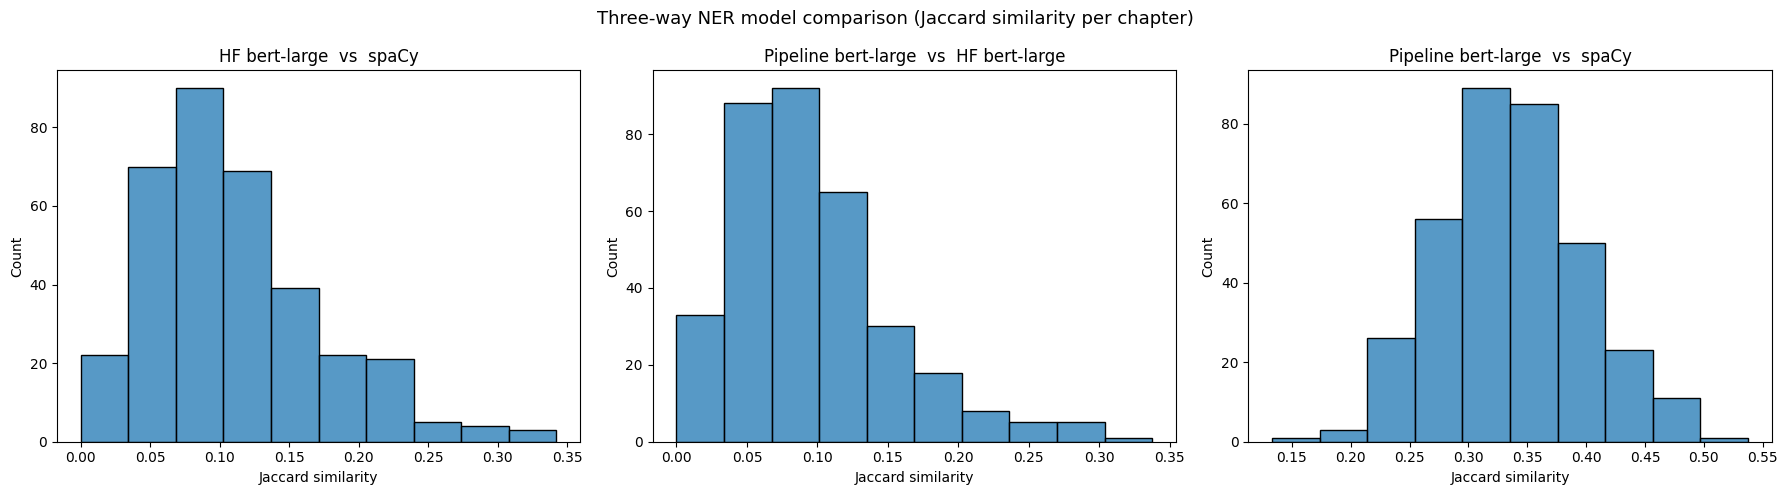


=== Model summary ===
  HF bert-large     – avg persons/chapter: 9.3
  spaCy trf         – avg persons/chapter: 62.4
  Pipeline bert-large – avg persons/chapter: 91.5

=== Pairwise Jaccard (mean) ===
  HF bert-large  vs spaCy          : 0.111
  Pipeline bert-large vs HF bert-large: 0.096
  Pipeline bert-large vs spaCy       : 0.336


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["jaccard"],             bins=10, ax=axes[0])
axes[0].set_title("HF bert-large  vs  spaCy")
axes[0].set_xlabel("Jaccard similarity")

sns.histplot(df["jaccard_PIPELINE_HF"], bins=10, ax=axes[1])
axes[1].set_title("Pipeline bert-large  vs  HF bert-large")
axes[1].set_xlabel("Jaccard similarity")

sns.histplot(df["jaccard_PIPELINE_SP"], bins=10, ax=axes[2])
axes[2].set_title("Pipeline bert-large  vs  spaCy")
axes[2].set_xlabel("Jaccard similarity")

plt.suptitle("Three-way NER model comparison (Jaccard similarity per chapter)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────
print("\n=== Model summary ===")
for col, label in [
    ("len_HF",       "HF bert-large    "),
    ("len_SP",       "spaCy trf        "),
    ("len_PIPELINE", "Pipeline bert-large"),
]:
    print(f"  {label} – avg persons/chapter: {df[col].mean():.1f}")

print("\n=== Pairwise Jaccard (mean) ===")
for col, label in [
    ("jaccard",             "HF bert-large  vs spaCy          "),
    ("jaccard_PIPELINE_HF", "Pipeline bert-large vs HF bert-large"),
    ("jaccard_PIPELINE_SP", "Pipeline bert-large vs spaCy       "),
]:
    print(f"  {label}: {df[col].mean():.3f}")

In [11]:
df

,book,title,text,persons,persons_HF,persons_SP,len_HF,len_SP,len_diff,set_HF,...,len_PIPELINE,set_PIPELINE,only_PIPELINE_vs_HF,only_HF_vs_PIPELINE,intersect_PIPELINE_HF,jaccard_PIPELINE_HF,only_PIPELINE_vs_SP,only_SP_vs_PIPELINE,intersect_PIPELINE_SP,jaccard_PIPELINE_SP
0,1,Prologue,"""We should start back,"" Gared urged as the woo...","[Ser Waymar Royce, Royce, Will, Wall, Gared, W...","[Ser Waymar Royce, Royce, Will, Wall, Gared, W...","[Waymar, Royce, Will, Wildling, Aemon, Mallist...",6,12,-6,"{Royce, Wall, Ser Waymar Royce, Will, Gared, W...",...,17,"{Mae, Royce, Wall, Two, Mormon, Waymar, Way, W...","{Mae, Two, Mormon, Waymar, Way, Mar, Mormont, ...","{Will, Ser Waymar Royce}","{Gared, Royce, Wall, Waymar Royce}",0.210526,"{Mae, Two, Wall, Mormon, Way, Mar, Maester Aem...","{Mallisters, Mallister, Will, Wildling, Aemon}","{Royce, Waymar, Gared, Mormont, Robert, Ser Wa...",0.318182
1,1,Bran,"The morning had dawned clear and cold, with a ...","[Robb, Bran, Jon, Mance Rayder, B, Old Nan]","[Robb, Bran, Jon, Mance Rayder, B, Old Nan]","[Father, Starks, Jory Cassel, Rickon, Baratheo...",6,27,-21,"{Bran, Robb, B, Old Nan, Mance Rayder, Jon}",...,32,"{Rob, Robb, Bran, Win, Eddard Stark, Stark, Ro...","{Rob, Win, Eddard Stark, Stark, Robert, Ser Ro...",{B},"{Robb, Bran, Old Nan, Mance Rayder, Jon}",0.151515,"{Rob, Bar, Win, Theon, Old Nan, Lord Stark, Wi...","{Tullys, Starks, Baratheon, Harwin, Targaryen,...","{Robb, Bran, Eddard Stark, Stark, Robert, Ice,...",0.475000
2,1,Catelyn,Catelyn had never liked this godswood.\n\tShe ...,"[At, Ned, Catelyn]","[At, Ned, Catelyn]","[Starks, Eyrie, Rickon, Tullys, Nan, Pycelle, ...",3,31,-28,"{Catelyn, Ned, At}",...,34,"{Bran, En, Stark, Pycelle, Robert, Brandon, Ry...","{Bran, En, Stark, Pycelle, Robert, Brandon, Ry...","{Catelyn, At}",{Ned},0.027778,"{En, Brandon, Rya, Rick, Ice, Old Nan, Eyr, Ca...","{Eyrie, Arya, Knight of the Gate, Tullys, Host...","{Tommen, Bran, Lysa, Luwin, Mance Rayder, Star...",0.274510
3,1,Daenerys,Her brother held the gown up for her inspectio...,"[Her, Illyrio, Dany, Drogo, Viserys, Be, Khal]","[Her, Illyrio, Dany, Drogo, Viserys, Be, Khal]","[Dany, Myr, Willem, Daenerys, Daenerys Stormbo...",7,39,-32,"{Be, Viserys, Drogo, Illyrio, Khal, Her, Dany}",...,66,"{Landing, Tyrell, Lannister, Stark, Se, Khal M...","{Lannister, Stark, Khal Moro, Free, Daenerys S...","{Her, Be}","{Viserys, Khal, Drogo, Illyrio, Dany}",0.073529,"{Landing, Se, Free, Battle, Mother, Ogo, Ys, I...","{Aegon the Conqueror, Volantis, Viserys of the...","{Tyrell, Lannister, Khal Moro, Stark, Daenerys...",0.235294
4,1,Eddard,The visitors poured through the castle gates i...,"[Sandor Clegane, A, Tyrion Lannister, Theon, J...","[Sandor Clegane, A, Tyrion Lannister, Theon, J...","[Father, Sandor Clegane, The Hand of the King,...",9,40,-31,"{Tyrion Lannister, Theon, Greyjoy, A, Sandor C...",...,49,"{En, Eddard Stark, Stark, Bo, D Stark, Robert,...","{En, Eddard Stark, Stark, Bo, D Stark, Rickard...",{A},"{Tyrion Lannister, Theon, Greyjoy, Sandor Cleg...",0.160000,"{En, Bo, D Stark, Lord Tywin, Theo, Ys, Ba, Me...","{Cersei, Lannister, The Hand of the King, Bara...","{Eddard Stark, Stark, Robert, Rickard Stark, J...",0.390625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,5,Jon,"Let them die,"" said Queen Selyse.\n\tIt was th...","[Malegorn, Selyse, Ser Dorden, Patchface, Wall...","[Malegorn, Selyse, Ser Dorden, Patchface, Wall...","[Starks, Cregan Karstark, Sealskinner, Leather...",20,84,-64,"{Wall, Axell Florent, Night, Patchface, Ser Pa...",...,124,"{Wall, Leathers, Melisandre Of, Shire, Melisan...","{Karst, Leathers, Tor, Soren Shieldbreaker, Me...","{Ser Patrek, Melisandre of, Do}","{Devan Seaworth, Wall, Shireen, Malegorn, Axel...",0.133858,"{Wall, Melisandre Of, Shire, Hands, Ma, Rick, ...","{Samwell Tarly, Thunderfist, Redbeard, Her Gra...","{Axell Florent, Leathers, Yarwyck, Soren Shiel...",0.268293
341,5,Trueborn Lord Of Winterfell.,"""Snow?"" s

In [12]:
from pathlib import Path

out_path = Path.cwd() / "data/GOT-NER-compare-3models.pickle"
out_path = Path(str(out_path).strip())  # remove hidden whitespace/newline if any
print("Saving to:", out_path)

df.to_pickle(out_path)
print("✅ Saved GOT-NER-compare-3models.pickle")

Saving to: g:\Mon Drive\2. Etude\7. Shanghai University\Cours\S2\Advanced Agile Data Analysis\GOT_relation_map\data\GOT-NER-compare-3models.pickle
✅ Saved GOT-NER-compare-3models.pickle


In [13]:
df_result = df[[
    "book", "title","text",
    "persons_HF", "persons_SP", "persons_PIPELINE",
    "len_HF", "len_SP", "len_PIPELINE",
]]
df_result

,book,title,text,persons_HF,persons_SP,persons_PIPELINE,len_HF,len_SP,len_PIPELINE
0,1,Prologue,"""We should start back,"" Gared urged as the woo...","[Ser Waymar Royce, Royce, Will, Wall, Gared, W...","[Waymar, Royce, Will, Wildling, Aemon, Mallist...","[Mae, Royce, Wall, Two, Mormon, Waymar, Way, F...",6,12,17
1,1,Bran,"The morning had dawned clear and cold, with a ...","[Robb, Bran, Jon, Mance Rayder, B, Old Nan]","[Father, Starks, Jory Cassel, Rickon, Baratheo...","[Rob, Robb, Bran, Win, Eddard Stark, Stark, Ro...",6,27,32
2,1,Catelyn,Catelyn had never liked this godswood.\n\tShe ...,"[At, Ned, Catelyn]","[Starks, Eyrie, Rickon, Tullys, Nan, Pycelle, ...","[Bran, En, Stark, Pycelle, Robert, Jon, Brando...",3,31,34
3,1,Daenerys,Her brother held the gown up for her inspectio...,"[Her, Illyrio, Dany, Drogo, Viserys, Be, Khal]","[Dany, Myr, Willem, Daenerys, Daenerys Stormbo...","[Landing, Tyrell, Lannister, Stark, Se, Khal M...",7,39,66
4,1,Eddard,The visitors poured through the castle gates i...,"[Sandor Clegane, A, Tyrion Lannister, Theon, J...","[Father, Sandor Clegane, The Hand of the King,...","[En, Eddard Stark, Stark, Bo, D Stark, Robert,...",9,40,49
...,...,...,...,...,...,...,...,...,...
340,5,Jon,"Let them die,"" said Queen Selyse.\n\tIt was th...","[Malegorn, Selyse, Ser Dorden, Patchface, Wall...","[Starks, Cregan Karstark, Sealskinner, Leather...","[Wall, Leathers, Melisandre Of, Shire, Melisan...",20,84,124
341,5,Trueborn Lord Of Winterfell.,"""Snow?"" said Tormund Giantsbane. ""You look lik...","[Mully, Satin, Tormund Giantsbane, Rattleshirt...","[Mully, Wun Wun's, Bowen Marsh, Rickon, Ygon O...","[Bran, Wall, Melisandre, Bowen Marsh, Ramsay S...",14,60,93
342,5,The Queen'S Hand,The Dornish prince was three days dying.\n\tHe...,"[Barristan, Missandei, Selmy, Ser Barristan, Q...","[The Green Grace, Straw, Widower, Astapor, Cat...","[Daenerys Targa, Viserion, Ions, Stalwart, Ymo...",8,93,146
343,5,Daenerys,The hill was a stony island in a sea of green....,"[Bay, Dany, Valyria, Daenerys, She, Drogon]","[Dany, Daenerys, Groleo, Khal Jhaqo, Ser Barri...","[Ith, Doreah, Sunset, Val, Ma, Ere, Daenerys, ...",6,44,92


In [14]:
out_path = Path.cwd() / "data/GOT-NER-compare-3models-final.pickle"
out_path = Path(str(out_path).strip())  # remove hidden whitespace/newline if any

df_result.to_pickle(out_path)
print("✅ Saved GOT-NER-compare-3models-final.pickle")

✅ Saved GOT-NER-compare-3models-final.pickle


### Network generation

In [15]:
import networkx as nx
from itertools import combinations

In [16]:
G = nx.Graph()

In [17]:
df = df_result[[
    "book", "title", 'text',
    "persons_PIPELINE"
]].rename(columns={"persons_PIPELINE": "persons"})

In [18]:
df.head()

,book,title,text,persons
0,1,Prologue,"""We should start back,"" Gared urged as the woo...","[Mae, Royce, Wall, Two, Mormon, Waymar, Way, F..."
1,1,Bran,"The morning had dawned clear and cold, with a ...","[Rob, Robb, Bran, Win, Eddard Stark, Stark, Ro..."
2,1,Catelyn,Catelyn had never liked this godswood.\n\tShe ...,"[Bran, En, Stark, Pycelle, Robert, Jon, Brando..."
3,1,Daenerys,Her brother held the gown up for her inspectio...,"[Landing, Tyrell, Lannister, Stark, Se, Khal M..."
4,1,Eddard,The visitors poured through the castle gates i...,"[En, Eddard Stark, Stark, Bo, D Stark, Robert,..."


In [19]:
G.add_node('A')
G.add_node('B')
G.add_edge('A', 'B')

In [20]:
G = nx.Graph()

def get_edges_for_chapter(row):
    p = row['persons']
    
    if row['title'] != 'Prologue':
        p = p + [row['title']]
        
    my_edges = list(combinations(p,2))
    G.add_edges_from(my_edges)
    
df.loc[:,['title', 'persons']].apply(get_edges_for_chapter, axis=1)

0      None
1      None
2      None
3      None
4      None
       ... 
340    None
341    None
342    None
343    None
344    None
Length: 345, dtype: object

In [21]:
len(G.nodes(data=True))

5408

In [22]:
len(G.edges)

913496

In [23]:
nx.write_gexf(G, './data/GOT-NER-map_global_v0.gexf')

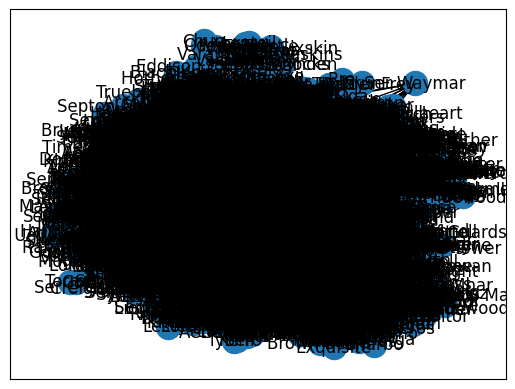

In [24]:
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos=pos, )